### Problem Statement

Write the problem statement and objectives here


**Description**

**Context**

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.



**Objective**

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company improve its business.

### Data Dictionary

Mention the data dictionary here

**Data Description**

The data includes various information related to a food order. A detailed data dictionary is provided below.

**Data Dictionary**

order_id: Unique ID of the order

customer_id: ID of the customer who ordered the food

restaurant_name: Name of the restaurant

cuisine_type: Cuisine ordered by the customer

cost_of_the_order: Cost of the order

day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)

rating: Rating given by the customer out of 5

food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.

delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# Write your code here to import necessary libraries for the project
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Understanding the structure of the data

In [ ]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Write your code here to read the data
file_path = '/content/drive/My Drive/Python Course/food.csv'
df = pd.read_csv(file_path)
print(df.head())

   order_id  customer_id            restaurant_name cuisine_type  \
0   1477147       337525                    Hangawi       Korean   
1   1477685       358141  Blue Ribbon Sushi Izakaya     Japanese   
2   1477070        66393                Cafe Habana      Mexican   
3   1477334       106968  Blue Ribbon Fried Chicken     American   
4   1478249        76942           Dirty Bird to Go     American   

   cost_of_the_order day_of_the_week     rating  food_preparation_time  \
0              30.75         Weekend  Not given                     25   
1              12.08         Weekend  Not given                     25   
2              12.23         Weekday          5                     23   
3              29.20         Weekend          3                     25   
4              11.59         Weekday          4                     25   

   delivery_time  
0             20  
1             23  
2             28  
3             15  
4             24  


In [ ]:
# Write your code here to view the first 5 rows
print(df.head(5))

   order_id  customer_id            restaurant_name cuisine_type  \
0   1477147       337525                    Hangawi       Korean   
1   1477685       358141  Blue Ribbon Sushi Izakaya     Japanese   
2   1477070        66393                Cafe Habana      Mexican   
3   1477334       106968  Blue Ribbon Fried Chicken     American   
4   1478249        76942           Dirty Bird to Go     American   

   cost_of_the_order day_of_the_week     rating  food_preparation_time  \
0              30.75         Weekend  Not given                     25   
1              12.08         Weekend  Not given                     25   
2              12.23         Weekday          5                     23   
3              29.20         Weekend          3                     25   
4              11.59         Weekday          4                     25   

   delivery_time  
0             20  
1             23  
2             28  
3             15  
4             24  


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# Write your code here
rows, columns = df.shape

# Print the result
print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Number of rows: 1898
Number of columns: 9


Observations:
The data has 1898 rows and 9 columns.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Write your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


Observations:
The three different datatypes are integer, object (string or mixed type) and float.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# Write your code here
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

Missing values per column:
 order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64


Observations:
There are no missing values in the rows for each column in the dataset.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# Write your code here
# statistical summary of the numerical data
df[['cost_of_the_order','food_preparation_time','delivery_time']].describe().T



,count,mean,std,min,25%,50%,75%,max
cost_of_the_order,1898.0,16.498851,7.483812,4.47,12.08,14.14,22.2975,35.41
food_preparation_time,1898.0,27.371970,4.632481,20.00,23.00,27.00,31.0000,35.00
delivery_time,1898.0,24.161749,4.972637,15.00,20.00,25.00,28.0000,33.00


Observations:

1. The average cost of an order is ~16.5, the average preparation time for an ordered food is 27.4 min, and the average delivery time for an order is 24.2 min.

2. Considering the interquartile ranges (IQR) for the three variables, none of them seem to have outliers.

3. Among the numerical variables, Cost of the Order has the largest coefficient of variation (CV). Specifically, CVs for Cost of the Order, Food Preparation Time, and Delivery Time are 0.45, 0.17, and 0.21, respectively.

4. None of the variables appear to be significantly skewed, but Cost of the Order has slight right skew (its mean is slightly larger than median).

5. **The minimum, average, and maximum times it takes for food to be prepared (from the restaurant's order confirmation to the delivery person's pick-up confirmation) are 20 min, 27.4 min, and 35 min, respectively.**

In [ ]:
# Statistical summary of the non-numerical data
df.describe(include=['category','object'])

,restaurant_name,cuisine_type,day_of_the_week,rating
count,1898,1898,1898,1898
unique,178,14,2,4
top,Shake Shack,American,Weekend,Not given
freq,219,584,1351,736


Observations:
1. Among the data, there are 178 unique Restaurant Names, 14 unique Cuisine Types, 2 unique Days of the Week, and 4 unique Rating inputs.

2. The most repeated values of the variables Restaurant Name, Cuisine Type, Day of the Week, and Rating are 'Shake Shack', 'American', 'Weekend', and 'Not given', respectively.

### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# Write the code here

not_rated_count = (df['rating'] == 'Not given').sum()
print(f"The total of orders that are not rated: {not_rated_count}")

The total of orders that are not rated: 736


Observations:
Using the value count function we could find the "Not given" answer in the 'rating' column appears 736 times.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

Since the question asks for exploring all the variables, Customer IDs and Restaurant Names are also considered here. However, due to the large number of their unique values, they are explored without graphs.

**Customers**

In [ ]:
# Number of unique Customer IDs
len(df.customer_id.unique())

1200

Observation: There are 1200 unique customers in the data.

In [ ]:
# Customer with most orders
df.customer_id.value_counts(sort=True)

,count
customer_id,
52832,13
47440,10
83287,9
250494,8
259341,7
...,...
385426,1
254913,1
289597,1


Observation: The maximum number of orders from a single customer is 13 and it belongs to Customer ID of 52832

**Restaurants**

In [ ]:
# Use unique() to find the number of unique Restaurant Names
len(df.restaurant_name.unique())

178

Observation: There are 178 unique restaurants in the data.

In [ ]:
# Use value_counts() to find the restaurant with most orders
df.restaurant_name.value_counts(sort=True)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68
...,...
Sushi Choshi,1
Dos Caminos Soho,1
La Follia,1


Observation: The restaurant with most orders is named "Shake Shack", which has received 219 orders.

**Cuisine**

In [ ]:
# Use unique() to find unique valuses of Cuisine Type
df.cuisine_type.unique()

array(['Korean', 'Japanese', 'Mexican', 'American', 'Indian', 'Italian',
       'Mediterranean', 'Chinese', 'Middle Eastern', 'Thai', 'Southern',
       'French', 'Spanish', 'Vietnamese'], dtype=object)

Observation: Cuisine Type has 14 unique values in the data, including 'Korean', 'Japanese', 'Mexican', 'American', 'Indian', 'Italian', 'Mediterranean', 'Chinese', 'Middle Eastern', 'Thai', 'Southern', 'French', 'Spanish', and 'Vietnamese'.

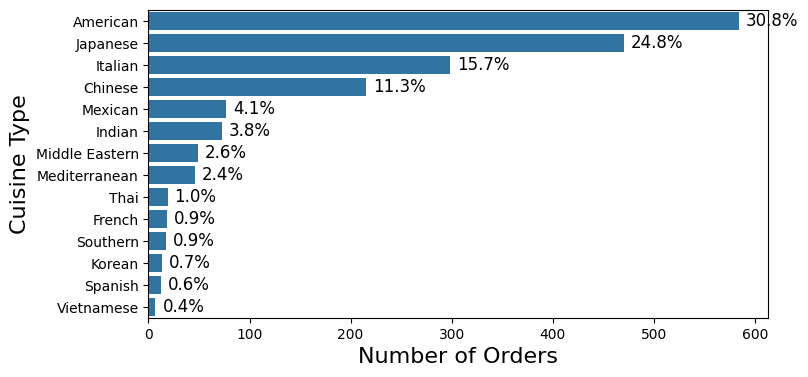

In [ ]:
# Use a countplot to explore distribution of different cuisine types
plt.figure(figsize = (8,4)) # set figure size
p1 = sns.countplot(y = df.cuisine_type, order = df.cuisine_type.value_counts().index) # create countplot

p1.set_xlabel("Number of Orders", fontsize = 16) # set x-axis label
p1.set_ylabel("Cuisine Type", fontsize = 16) # set y-axis label

for p in p1.patches: # add percentage labels
        label = "{:.1f}%".format(100.0*p.get_width() / df.cuisine_type.value_counts().sum())

        y = p.get_y() + p.get_height()/2  # y coordinate of bar percentage label
        x = p.get_width()  # x coordinate of bar percentage label

        p1.annotate(label,(x, y), ha="left", va="center", size=12, xytext=(5, 0), textcoords="offset points")

Observation: The most popular cuisine is found to be American, which constitutes almost 30.8% of the Cuisine Types. The least popular cuisine is Vietnamese, constituting only 0.4% of the Cuisine Types.

**Order Cost**

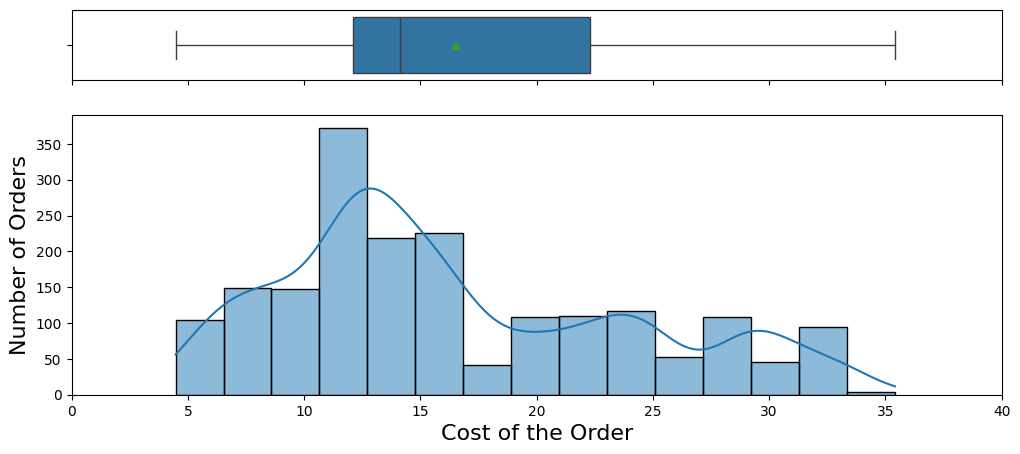

In [ ]:
# Use boxplot + histogram to explore distribution of order costs
# create subplots of two rows and one column
p2, (row1, row2) = plt.subplots(nrows = 2, ncols = 1, sharex = True, gridspec_kw={"height_ratios": (0.2, 0.8)}, figsize = (12,5))

sns.boxplot(ax = row1, x = df.cost_of_the_order, showmeans = True) # create box plot on 1st row
sns.histplot(ax = row2, x = df.cost_of_the_order, kde = True, binwidth = 2) # create histogram on 2nd row

row1.set_xlabel("", fontsize = 16) # remove label of 1st x-axis
row2.set_xlabel("Cost of the Order", fontsize = 16) # set 2nd x-axis label
row2.set_ylabel("Number of Orders", fontsize = 16); # set y-axis label
row2.set_xlim([0,40]) # set x-axis limits
row2.set_xticks(range(0,41,5)); # set x-axis ticks

Observations:

The distribution is slightly right-skewed (mean > median).
The cost of an order ranges from almost 4.5 to 35.4, while the median cost is 14.1.
A large portion of order costs are between ~10 and ~17.

**Order Day**

In [ ]:
# Use unique() to find unique valuses of Day of the Week
df.day_of_the_week.unique()

array(['Weekend', 'Weekday'], dtype=object)

Observation: This variable takes only one of the two values: 'Weekend' and 'Weekday'.

<ipython-input-63-b08e2a5e116e>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  p3 = sns.countplot(y = df.day_of_the_week, order = df.day_of_the_week.value_counts().index, palette = 'Set2') # create countplot


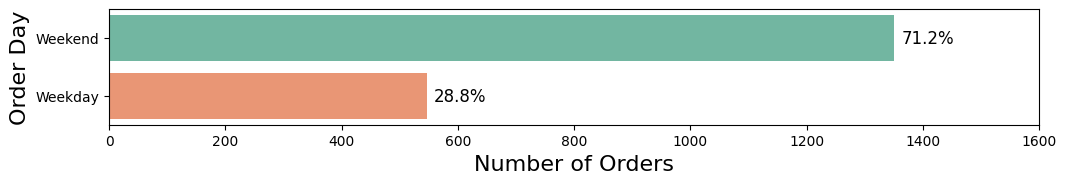

In [ ]:
# Use a countplot to explore distribution of different order days
plt.figure(figsize = (12,1.5)) # set figure size
p3 = sns.countplot(y = df.day_of_the_week, order = df.day_of_the_week.value_counts().index, palette = 'Set2') # create countplot

p3.set_xlabel("Number of Orders", fontsize = 16) # set x-axis label
p3.set_ylabel("Order Day", fontsize = 16) # set y-axis label
p3.set_xlim([0,1600]) # set x-axis limits

for p in p3.patches: # add percentage labels
        label = "{:.1f}%".format(100.0*p.get_width() / df.cuisine_type.value_counts().sum())

        y = p.get_y() + p.get_height()/2  # y coordinate of bar percentage label
        x = p.get_width()  # x coordinate of bar percentage label

        p3.annotate(label,(x, y), ha="left", va="center", size=12, xytext=(5, 0), textcoords="offset points")

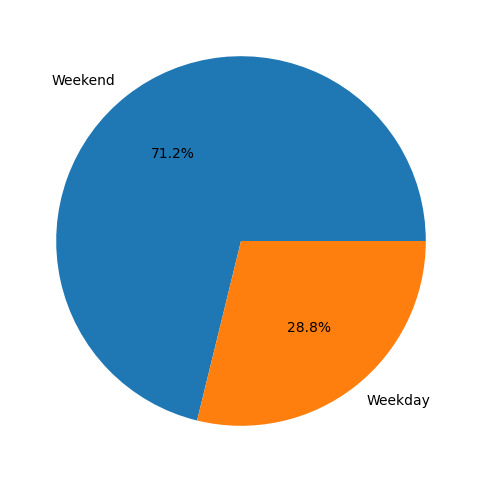

In [ ]:
# ALTERNATIVELY: Use a pie chart to explore distribution of order days
plt.figure(figsize = (6,6)) # set figure size
plt.pie(df.day_of_the_week.value_counts(sort = False), labels = df.day_of_the_week.unique(), autopct = '%1.1f%%');

Observation: More than 71% of the orders are placed during the weekend.

**Rating**

In [ ]:
# Use unique() to find unique valuses of Rating
df.rating.unique()

array(['Not given', '5', '3', '4'], dtype=object)

Observation: The customers have either given a rating above 3 (3, 4, or 5) to their order experience or have not given any rating.

<ipython-input-66-a0638bb3b16e>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  p4 = sns.countplot(y = df.rating, order = df.rating.value_counts().index, palette = 'Set2') # create countplot


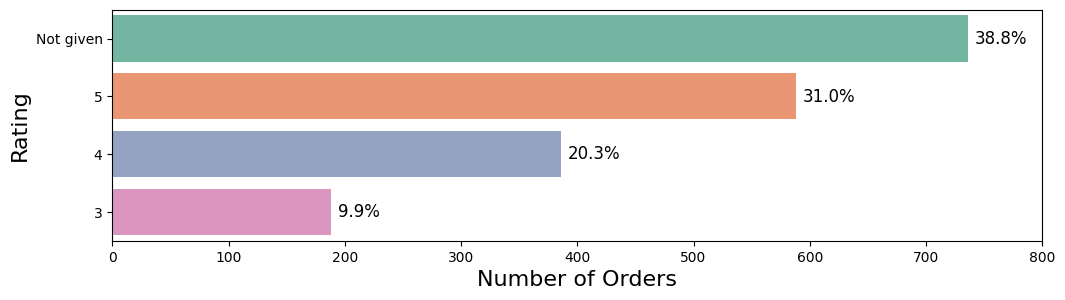

In [ ]:
# Use a countplot to explore distribution of ratings
plt.figure(figsize = (12,3)) # set figure size
p4 = sns.countplot(y = df.rating, order = df.rating.value_counts().index, palette = 'Set2') # create countplot

p4.set_xlabel("Number of Orders", fontsize = 16) # set x-axis label
p4.set_ylabel("Rating", fontsize = 16) # set y-axis label
p4.set_xlim([0,800]) # set x-axis limits

for p in p4.patches: # add percentage labels
        label = "{:.1f}%".format(100.0*p.get_width() / df.cuisine_type.value_counts().sum())

        y = p.get_y() + p.get_height()/2  # y coordinate of bar percentage label
        x = p.get_width()  # x coordinate of bar percentage label

        p4.annotate(label,(x, y), ha="left", va="center", size=12, xytext=(5, 0), textcoords="offset points")

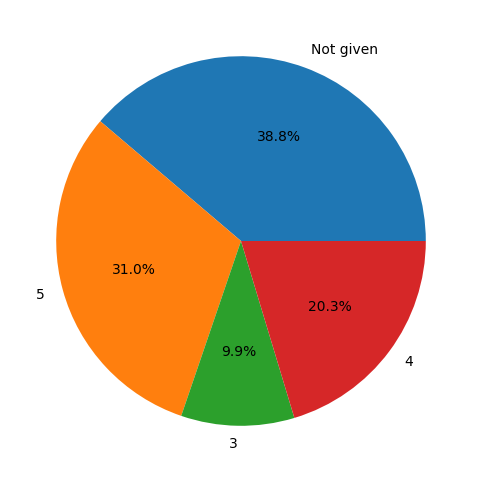

In [ ]:
# ALTERNATIVELY: Use a pie chart to explore distribution of ratings
plt.figure(figsize = (6,6)) # set figure size
plt.pie(df.rating.value_counts(sort = False), labels = df.rating.unique(), autopct = '%1.1f%%');

Observations:

1. The majority (~39%) of the orders have not been given any ratings.
2. Among the given ratings, the majority (31%) are 5.
3. The least number of orders (~10%) have been given a rating of 3.

**Food Preparation Time**

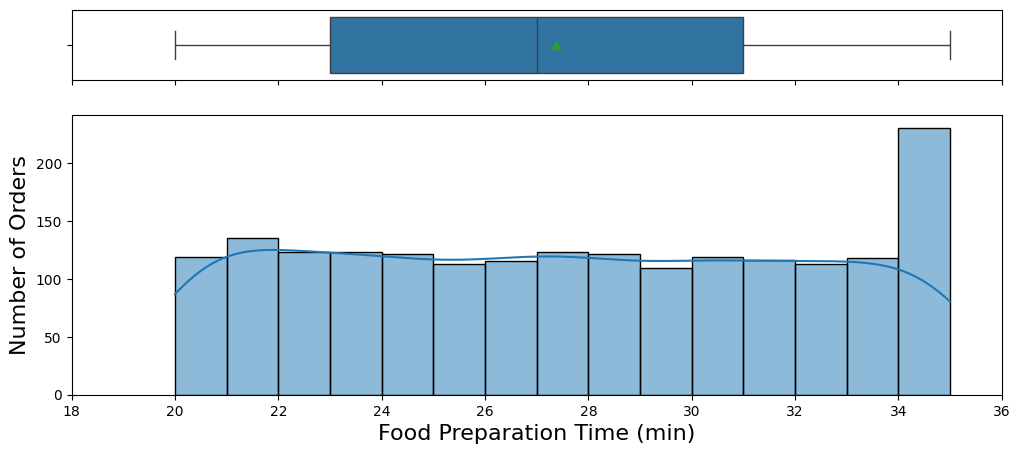

In [ ]:
# Use boxplot + histogram to explore distribution of food preparation time
p5, (row1, row2) = plt.subplots(nrows = 2, ncols = 1, sharex = True, # create subplots of two rows and one column
                                gridspec_kw={"height_ratios": (0.2, 0.8)}, figsize = (12,5))

sns.boxplot(ax = row1, x = df.food_preparation_time, showmeans = True) # create box plot on 1st row
sns.histplot(ax = row2, x = df.food_preparation_time, kde = True, binwidth = 1) # create histogram on 2nd row

row1.set_xlabel('', fontsize = 16) # remove label of 1st x-axis
row2.set_xlabel('Food Preparation Time (min)', fontsize = 16) # set 2nd x-axis label
row2.set_ylabel('Number of Orders', fontsize = 16); # set y-axis label
row2.set_xlim([18,36]) # set x-axis limits
row2.set_xticks(range(18,37,2)); # set x-axis ticks

Observations:

1. The distribution is relatively uniform and mean (27.4 min) and median (27 min) are very close.
2. Each food preparation takes between 20 and 35 min.

**Delivery Time**

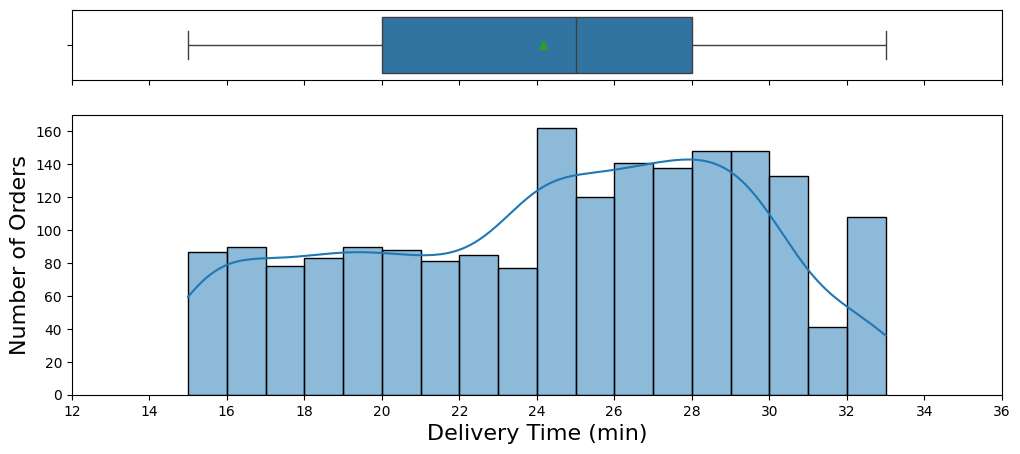

In [ ]:
# Use boxplot + histogram to explore distribution of delivery time
p6, (row1, row2) = plt.subplots(nrows = 2, ncols = 1, sharex = True, # create subplots of two rows and one column
                                gridspec_kw={"height_ratios": (0.2, 0.8)}, figsize = (12,5))

sns.boxplot(ax = row1, x = df.delivery_time, showmeans = True) # create box plot on 1st row
sns.histplot(ax = row2, x = df.delivery_time, kde = True, binwidth = 1) # create histogram on 2nd row

row1.set_xlabel('', fontsize = 16) # remove label of 1st x-axis
row2.set_xlabel('Delivery Time (min)', fontsize = 16) # set 2nd x-axis label
row2.set_ylabel('Number of Orders', fontsize = 16) # set y-axis label
row2.set_xlim([12,36]) # set x-axis limits
row2.set_xticks(range(12,37,2)); # set x-axis ticks

Observations:

1. The distribution is not much skewed and mean (24.2 min) and median (25 min) are close.
2. Orders take between 15 and 33 min to be delivered.
3. A large number of orders take between 24 and 31 min to be delivered.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
# Write the code here
# Use value_counts() to find the top five restaurant with most orders
df.restaurant_name.value_counts(sort=True)[0:5]

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:
According to the above series, the top 5 restaurants in terms of received number of orders are 'Shake Shack', 'The Meatball Shop', 'Blue Ribbon Sushi', 'Blue Ribbon Fried Chicken', and 'Parm'.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# Write the code here
# Using Pandas DataFrame methods
cuisine_weekend = df.cuisine_type[df.day_of_the_week == 'Weekend'] # form the series of cuisine types for orders over weekends
cuisine_weekend.value_counts(sort = True) # use value_counts() to obtain the number of orders for each cuisine

,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53
Indian,49
Mediterranean,32
Middle Eastern,32
Thai,15


<ipython-input-72-da9a1cde85ed>:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p7.set_xticklabels(p7.get_xticklabels(),rotation = 90) # change orientation of x-axis ticks


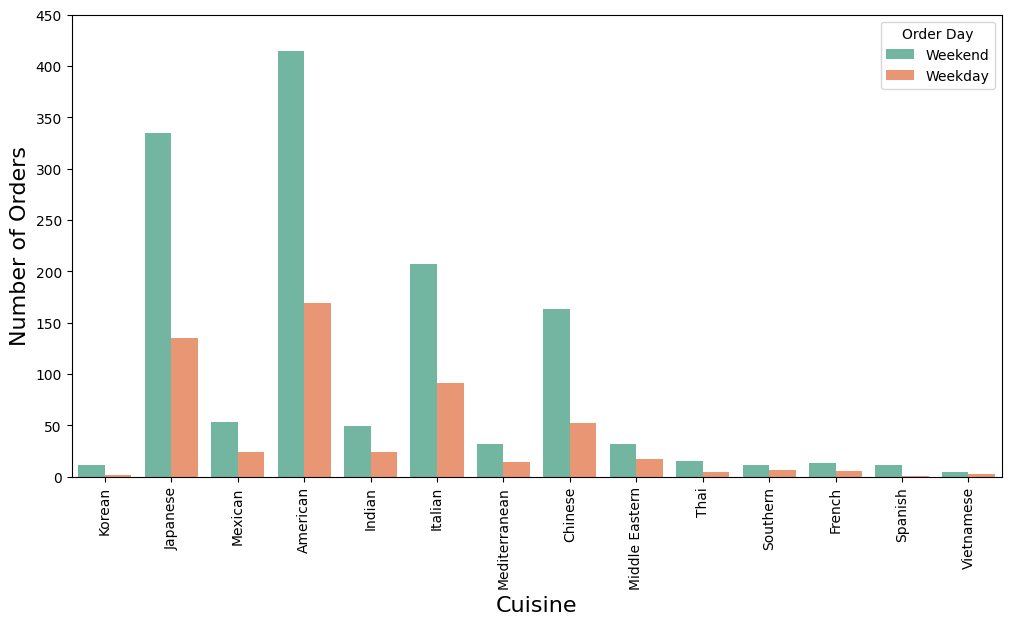

In [ ]:
# Using plots
plt.figure(figsize = (12,6)) # set figure size
p7 = sns.countplot(data = df, x = 'cuisine_type', hue = 'day_of_the_week', palette = 'Set2');
# create a countplot with grouped bars

p7.set_xticklabels(p7.get_xticklabels(),rotation = 90) # change orientation of x-axis ticks
p7.set_xlabel("Cuisine", fontsize = 16) # set x-axis label
p7.set_ylabel("Number of Orders", fontsize = 16) # set y-axis label
p7.set_ylim([0,450]) # set y-axis limits
p7.legend(title='Order Day'); # set legend title

#### Observations:

The most pupular cuisine on weekends is American, with 415 instances.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Write the code here
# Use logical indexing to identify orders costing above 20 and sum True (1) values
cost_above_20_orders = (df.cost_of_the_order > 20).sum() # number of orders costing above 20
total_orders = df.shape[0] # total number of orders
print('Orders Costing Above 20: ', round(100*cost_above_20_orders/total_orders, 1), '%', sep = '') # print rounded percentage

Orders Costing Above 20: 29.2%


Observations:
About 29.2% of the orders cost above 20.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# Write the code here
round( df['delivery_time'].mean(),2) ##Calculate the mean and rounding the answer to 2 decimal points.

24.16

Observations:
The average delivery time for the delivery to arrive to customers once its been picked up is 24.16 minutes.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# Write the code here
df['customer_id'].value_counts().nlargest(3) ##Find the 3 most repeat customers.

,count
customer_id,
52832,13
47440,10
83287,9


Observations:
The 3 customer id's that had the most frequent orders are id 52832:13 orders, 47440:10 orders, and 83287: 9 orders. These customers would receive the 20 % discount vouchers.


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


In [ ]:
# Write the code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


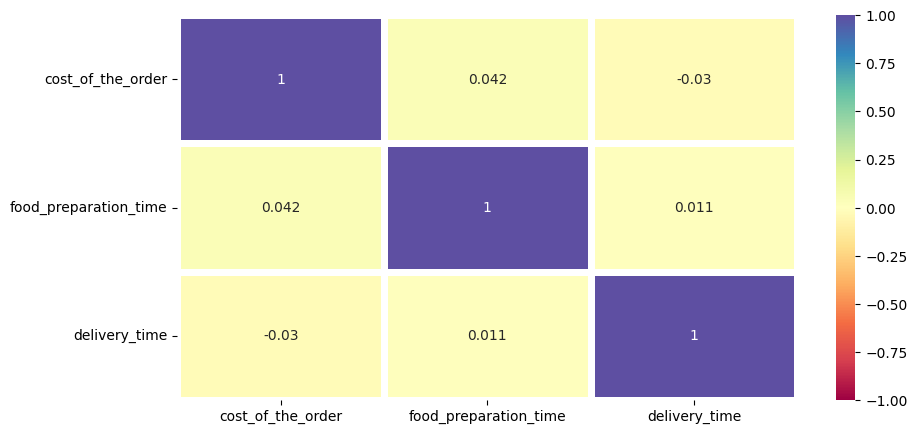

In [ ]:
col_list = ['cost_of_the_order','food_preparation_time','delivery_time'] ##List the numerical variables.
plt.figure(figsize=(10,5))
sns.heatmap(df[col_list].corr(),annot=True,cmap='Spectral',vmin=-1,vmax=1,linewidths=5) ##Create heatmap and see the correlation between numerical variables.
plt.show()

For the three numerical variables cost_of_the_order, food_preparation_time and delivery_time there appears to be no correlation. This establishes that there is no relationship in these variables. Order and customer id are just identifiers so even though they are numerical we can ignore for the correlation map.

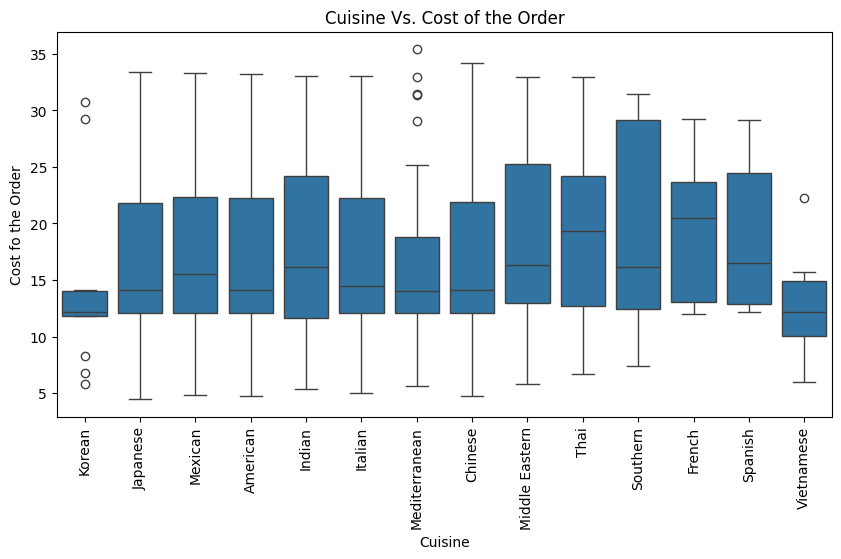

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df,x='cuisine_type',y='cost_of_the_order')
plt.xticks(rotation=90);
plt.title('Cuisine Vs. Cost of the Order')
plt.xlabel('Cuisine')
plt.ylabel('Cost fo the Order')
plt.show()

We could see in these boxplots that most cuisines had a cost from about 10 to 25 dollars per order. Few outliers were observed but these could be normal since eating habits could differ.

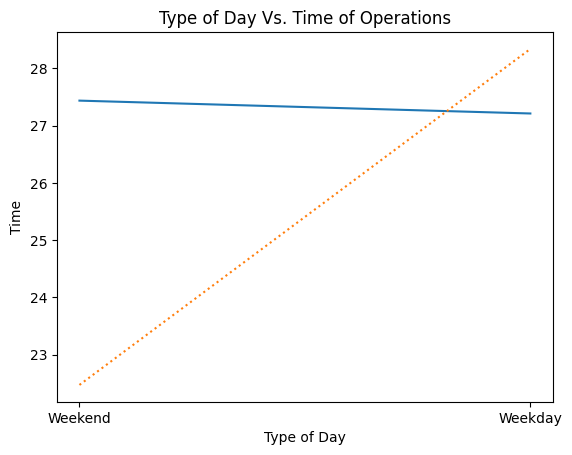

In [ ]:
sns.lineplot(data=df,x='day_of_the_week',y='food_preparation_time', errorbar=None)

sns.lineplot(data=df,x='day_of_the_week',y='delivery_time',errorbar=None, linestyle='dotted')
plt.title('Type of Day Vs. Time of Operations')
plt.xlabel('Type of Day')
plt.ylabel('Time')
plt.show();

On this chart we want to explore the relationship between type of day and time to prepare the order as well as the time to deliver. We clearly see order preparation is steadily the same (blue line). The time it takes to deliver the order on the weekend takes about 5 minutes less(dotted line).

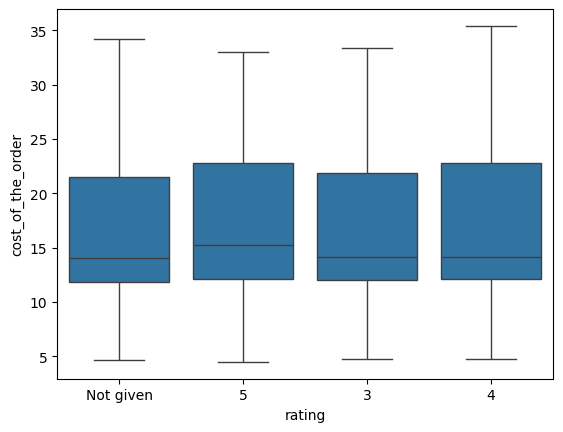

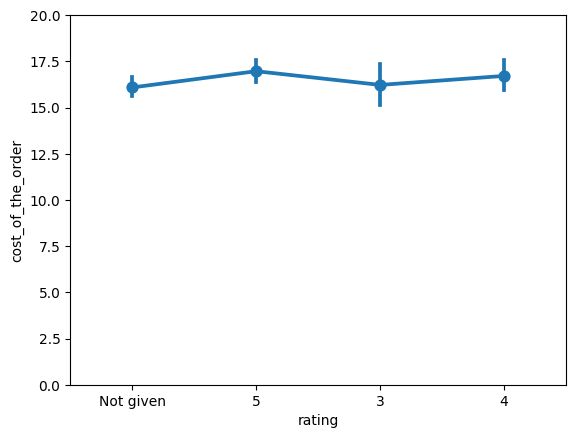

In [ ]:
sns.boxplot(data=df, x='rating', y ='cost_of_the_order')
plt.yticks(rotation=0);
plt.show()
plt.figure()
sns.pointplot(data= df, x = 'rating', y = 'cost_of_the_order')
plt.ylim(0,20)
plt.show()

On these boxplots I am investigating if cost affected the ratings for the orders. We could see that the relationship of cost of the order and rating given is negligible. Upon closer look the ratings have central tendencies from 16.00 and 17.00 dollars.

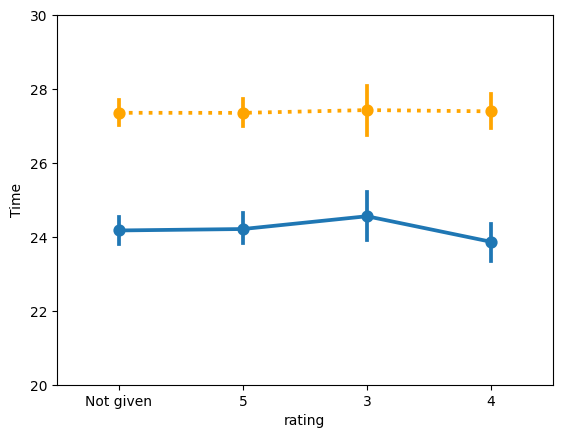

In [ ]:
plt.figure()
sns.pointplot(data= df, x = 'rating', y = 'delivery_time')  ## Plotting points to see how time categories affected ratings.
sns.pointplot(data= df, x = 'rating', y = 'food_preparation_time', color = 'orange' ,linestyles= 'dotted')
plt.ylabel('Time')
plt.ylim(20,30)
plt.show()

Comparing rating and delivery time (blue line) there appears to be no relationship. This is also true for food preparation time (orange line). This means time has no affect on customer ratings on orders.

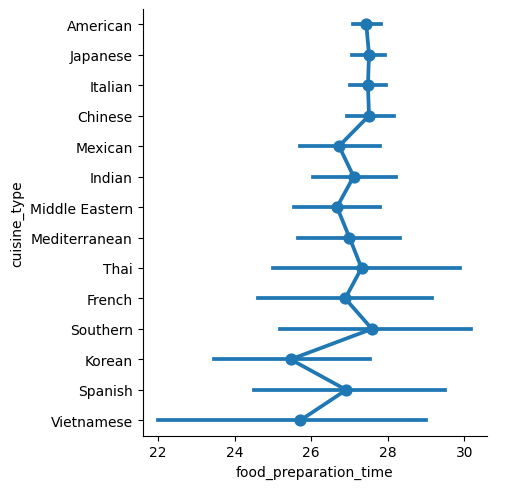

In [ ]:
sns.catplot(data=df, x='food_preparation_time', y='cuisine_type', kind='point', order=df['cuisine_type'].value_counts().index)
plt.show()

Observations:
Some of the most popular food types present strong consistency between their preparation times, suggesting that this also could be a factor in their popularity. Again here, more research is indicated.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# Write the code here
df.groupby(['restaurant_name'])['rating'].value_counts().nlargest(10) ##Find the top 10 rating counts for the rating category.

restaurant_name            rating   
Shake Shack                Not given    86
                           5            60
The Meatball Shop          5            53
Shake Shack                4            50
The Meatball Shop          Not given    48
Blue Ribbon Sushi          Not given    46
Blue Ribbon Fried Chicken  5            32
                           Not given    32
Blue Ribbon Sushi          5            32
Parm                       Not given    29
Name: count, dtype: int64

In [ ]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')## This line is to convert rating values to numeric and giving nan for the ratings that were not given.
rest_rating = df.groupby(['restaurant_name'])['rating'].agg(['mean','count'])##This is to create columns that give average ratings for each restaurant and count how many ratings were given.
rest_rating =  rest_rating[(rest_rating['mean'] > 4) & (rest_rating['count'] > 50)]## This is to filter out which results are above 4 rating and number of reviews above 50.
print(rest_rating)

                               mean  count
restaurant_name                           
Blue Ribbon Fried Chicken  4.328125     64
Blue Ribbon Sushi          4.219178     73
Shake Shack                4.278195    133
The Meatball Shop          4.511905     84


Observations:
The four restaurants that fit the promotional offer criteria are Shake Shack, The Meatball Shop, Blue Ribbon Fried Chicken and Blue Ribbon Sushi. These were the only restaurants that had over 50 orders and average rating above 4.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# Write the code here
over_20 = df[df['cost_of_the_order'] > 20] ##Create data frame with filtered cost of orders that are over 20 dollars
over_20_sum = over_20['cost_of_the_order'].sum() ## Sum the column cost of the order for all orders 20 dollars

over_5 = df[(df['cost_of_the_order'] >5) & (df['cost_of_the_order'] <= 20 )] ##Create data frame with filtered cost of orders between 5 to 20 dollars
over_5_sum = over_5['cost_of_the_order'].sum() ## Sum the column cost of the order for all orders of 5 to 20 dollars

total_revenue = over_20_sum * .25 + over_5_sum * .15 ##Arithmetic for the total revenue for the company
print(round(total_revenue,2))

6166.3


Observations:
The net revenue for the company is $6166.30 . As we see in the above code we used conditional operators to sum all the revenue.

#### Observations:


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# Write the code here
df['total_time'] = df['delivery_time'] + df['food_preparation_time'] #created new column summing up delivery time and food prep
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20,45
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23,48
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28,51
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15,40
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24,49


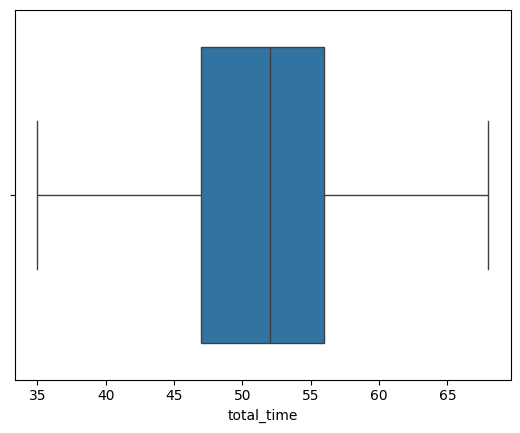

In [ ]:
sns.boxplot(data=df,x='total_time')
plt.show()

In [ ]:
order_over_60tt =  df[df['total_time'] > 60] ##Filter out the orders that are 60 minutes or more
order_count_60tt = order_over_60tt['total_time'].count().sum() ## Total count the number of orders
print(order_count_60tt)

total_observations=df['order_id'].count()
perc_total =  round((order_count_60tt/total_observations)*100,2) ##Percentage of orders over 60 minutes
print(perc_total)


200
10.54


Observations:
The total amount of orders that are over 60 minutes (total_time) is 200 orders. This is about 10.54% of all orders. This could be estimated using the box plot for total time where 60 minute mark is intersects on the whisker. This means at least 75% of the orders took less than 60 minutes.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

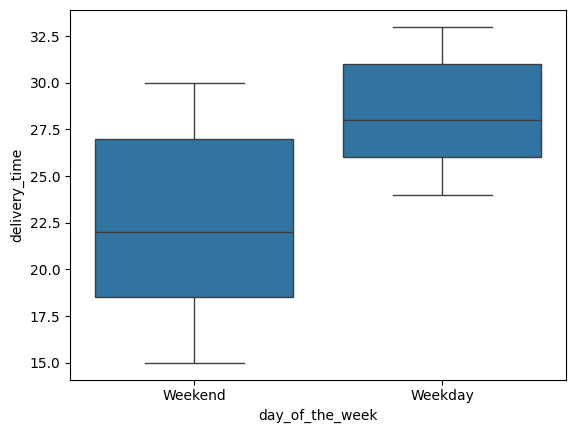

In [ ]:
# Write the code here
sns.boxplot(data=df,x='day_of_the_week',y='delivery_time')
plt.show()

(0.0, 30.0)

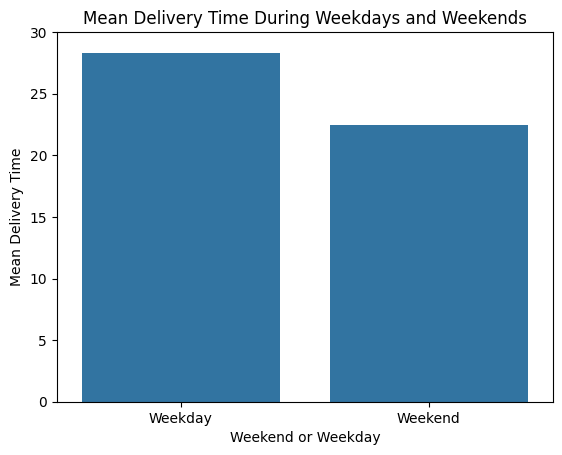

In [ ]:
mean_delivery = df.groupby(['day_of_the_week'])['delivery_time'].mean()
sns.barplot(x=mean_delivery.index, y=mean_delivery.values)

plt.title('Mean Delivery Time During Weekdays and Weekends')
plt.xlabel('Weekend or Weekday')
plt.ylabel('Mean Delivery Time')
plt.ylim(0, 30)

In [ ]:
print(mean_delivery)

day_of_the_week
Weekday    28.340037
Weekend    22.470022
Name: delivery_time, dtype: float64


Observations:
The average time that it took for orders to be delivered to customers after it was picked up is in the weekday 28 minutes about 6 minutes increase compared to weekend deliveries.


### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

Conclusions:
For this project we analyzed a dataset of 1898 food orders for the app FoodHub. The main focus is to see the relationship that feedback ratings had with other variables in the data set. Historically apps rely in ratings for the purpose of recomending restaurants to drive business. Also there are variables in this dataset that could help identify factors that affect efficiency of order deliveries. Here are some insights:

From the 12 types of cuisine types the 4 most popular cuisine types are Japanese, American, Italian and Chinese with 200+ orders.

Delivery time of orders on average are 6 minutes longer during the week day (28 minutes) compared to the weekend (22 minutes).

Feedback ratings are unaffected by increased cost of the orders.

Feedback ratings are unaffected by increased delivery time.

Increased demand for orders occur during the weekend.

10% of all orders take over 60 minutes to arrive at customers location.

### Recommendations:

Further investigate factors that increase delivery times on the weekdays.

Add further restaurants from the top four popular cuisines types.

Incentivize promotions for customers to order over $20.00 to increase the revenue.

More data should be procured so we have a deeper understanding on ratings and its relationship to times, cuisines and cost.